In [2]:
!pip install pandas pyarrow

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd

df = pd.read_parquet(
    "nyc.parquet",
    columns=["request_datetime", "PULocationID"]
)

print(df.head())

     request_datetime  PULocationID
0 2026-01-01 00:50:37           262
1 2026-01-01 00:09:12           195
2 2026-01-01 00:16:16            25
3 2026-01-01 00:08:19           141
4 2026-01-01 00:21:16           226


In [4]:
df.shape

(20940373, 2)

In [5]:
df.head()

,request_datetime,PULocationID
0,2026-01-01 00:50:37,262
1,2026-01-01 00:09:12,195
2,2026-01-01 00:16:16,25
3,2026-01-01 00:08:19,141
4,2026-01-01 00:21:16,226


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20940373 entries, 0 to 20940372
Data columns (total 2 columns):
 #   Column            Dtype         
---  ------            -----         
 0   request_datetime  datetime64[us]
 1   PULocationID      int32         
dtypes: datetime64[us](1), int32(1)
memory usage: 239.6 MB


In [7]:
df.isnull().sum()

request_datetime    0
PULocationID        0
dtype: int64

In [8]:
df['hour'] = df['request_datetime'].dt.hour
df['minute_slot'] = df['request_datetime'].dt.minute // 15
df['dow'] = df['request_datetime'].dt.weekday
df['date'] = df['request_datetime'].dt.date

In [9]:
df.head()

,request_datetime,PULocationID,hour,minute_slot,dow,date
0,2026-01-01 00:50:37,262,0,3,3,2026-01-01
1,2026-01-01 00:09:12,195,0,0,3,2026-01-01
2,2026-01-01 00:16:16,25,0,1,3,2026-01-01
3,2026-01-01 00:08:19,141,0,0,3,2026-01-01
4,2026-01-01 00:21:16,226,0,1,3,2026-01-01


In [10]:
#Agrregation
demand = df.groupby(["PULocationID",'hour','date',"dow"]).size().reset_index(name = 'demand')

In [11]:
print(demand.head())

   PULocationID  hour        date  dow  demand
0             1     4  2026-01-28    2       1
1             1    12  2026-01-29    3       1
2             2     0  2026-01-18    6       1
3             2     1  2026-01-19    0       1
4             2     6  2026-01-30    4       1


In [12]:
demand.to_csv("aggregated_demand.csv" , index= False)

In [13]:
demand

,PULocationID,hour,date,dow,demand
0,1,4,2026-01-28,2,1
1,1,12,2026-01-29,3,1
2,2,0,2026-01-18,6,1
3,2,1,2026-01-19,0,1
4,2,6,2026-01-30,4,1
...,...,...,...,...,...
187549,265,23,2026-01-25,6,1
187550,265,23,2026-01-26,0,1
187551,265,23,2026-01-27,1,1
187552,265,23,2026-01-28,2,1


In [14]:
demand = demand.sort_values(["PULocationID","date","hour"])

In [15]:
demand

,PULocationID,hour,date,dow,demand
0,1,4,2026-01-28,2,1
1,1,12,2026-01-29,3,1
5,2,8,2026-01-01,3,1
9,2,12,2026-01-01,3,1
28,2,21,2026-01-02,4,1
...,...,...,...,...,...
187446,265,18,2026-01-31,5,3
187474,265,19,2026-01-31,5,5
187492,265,20,2026-01-31,5,3
187517,265,21,2026-01-31,5,4


In [16]:

demand['pre_demand'] = demand.groupby("PULocationID")["demand"].shift(1)

In [17]:
demand

,PULocationID,hour,date,dow,demand,pre_demand
0,1,4,2026-01-28,2,1,NaN
1,1,12,2026-01-29,3,1,1.0
5,2,8,2026-01-01,3,1,NaN
9,2,12,2026-01-01,3,1,1.0
28,2,21,2026-01-02,4,1,1.0
...,...,...,...,...,...,...
187446,265,18,2026-01-31,5,3,6.0
187474,265,19,2026-01-31,5,5,3.0
187492,265,20,2026-01-31,5,3,5.0
187517,265,21,2026-01-31,5,4,3.0


In [18]:
demand.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187554 entries, 0 to 187553
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   PULocationID  187554 non-null  int32  
 1   hour          187554 non-null  int32  
 2   date          187554 non-null  object 
 3   dow           187554 non-null  int32  
 4   demand        187554 non-null  int64  
 5   pre_demand    187292 non-null  float64
dtypes: float64(1), int32(3), int64(1), object(1)
memory usage: 7.9+ MB


In [19]:
demand = demand.reset_index(drop =True)

In [20]:
demand

,PULocationID,hour,date,dow,demand,pre_demand
0,1,4,2026-01-28,2,1,NaN
1,1,12,2026-01-29,3,1,1.0
2,2,8,2026-01-01,3,1,NaN
3,2,12,2026-01-01,3,1,1.0
4,2,21,2026-01-02,4,1,1.0
...,...,...,...,...,...,...
187549,265,18,2026-01-31,5,3,6.0
187550,265,19,2026-01-31,5,5,3.0
187551,265,20,2026-01-31,5,3,5.0
187552,265,21,2026-01-31,5,4,3.0


In [21]:
demand[demand["PULocationID"] == 261].tail(10)

,PULocationID,hour,date,dow,demand,pre_demand
185545,261,14,2026-01-31,5,134,108.0
185546,261,15,2026-01-31,5,128,134.0
185547,261,16,2026-01-31,5,140,128.0
185548,261,17,2026-01-31,5,143,140.0
185549,261,18,2026-01-31,5,147,143.0
185550,261,19,2026-01-31,5,181,147.0
185551,261,20,2026-01-31,5,164,181.0
185552,261,21,2026-01-31,5,128,164.0
185553,261,22,2026-01-31,5,110,128.0
185554,261,23,2026-01-31,5,95,110.0


In [22]:
demand = demand.dropna()
demand = demand.reset_index(drop=True)
demand

,PULocationID,hour,date,dow,demand,pre_demand
0,1,12,2026-01-29,3,1,1.0
1,2,12,2026-01-01,3,1,1.0
2,2,21,2026-01-02,4,1,1.0
3,2,10,2026-01-05,0,1,1.0
4,2,16,2026-01-05,0,1,1.0
...,...,...,...,...,...,...
187287,265,18,2026-01-31,5,3,6.0
187288,265,19,2026-01-31,5,5,3.0
187289,265,20,2026-01-31,5,3,5.0
187290,265,21,2026-01-31,5,4,3.0


In [23]:
demand = demand[["PULocationID","hour","date","dow","pre_demand","demand"]]
demand

,PULocationID,hour,date,dow,pre_demand,demand
0,1,12,2026-01-29,3,1.0,1
1,2,12,2026-01-01,3,1.0,1
2,2,21,2026-01-02,4,1.0,1
3,2,10,2026-01-05,0,1.0,1
4,2,16,2026-01-05,0,1.0,1
...,...,...,...,...,...,...
187287,265,18,2026-01-31,5,6.0,3
187288,265,19,2026-01-31,5,3.0,5
187289,265,20,2026-01-31,5,5.0,3
187290,265,21,2026-01-31,5,3.0,4


In [24]:
demand['date'].nunique()

32

In [25]:
print(demand["date"].min())
print(demand["date"].max())

2026-01-01
2026-02-01


In [69]:
#eda
x = demand.iloc[:,0:4]
y= demand.iloc[:,-1]
x

,PULocationID,hour,dow,pre_demand
0,1,12,3,1.0
1,2,12,3,1.0
2,2,21,4,1.0
3,2,10,0,1.0
4,2,16,0,1.0
...,...,...,...,...
187287,265,18,5,6.0
187288,265,19,5,3.0
187289,265,20,5,5.0
187290,265,21,5,3.0


In [70]:
x.shape

(187292, 4)

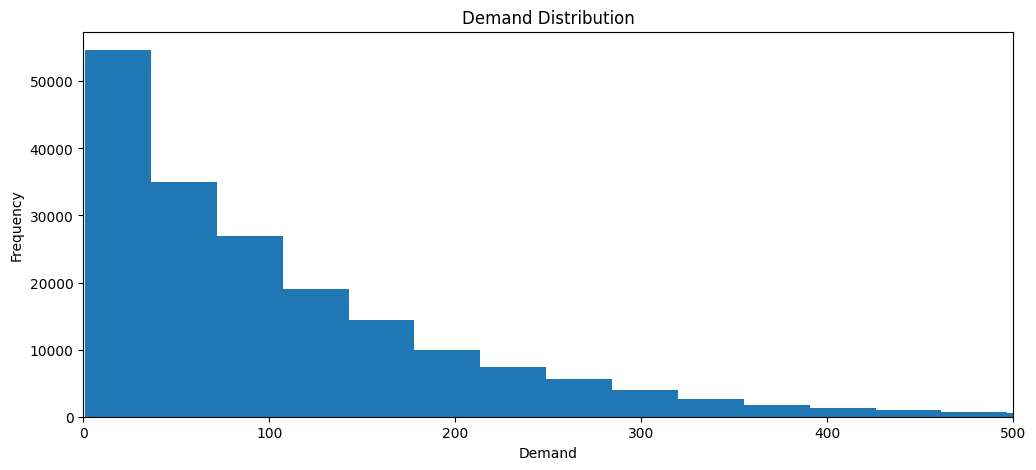

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.hist(demand["demand"], bins=50)
plt.xlim(0,500)
plt.title("Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.show()

C:\Users\koner\AppData\Local\Temp\ipykernel_4784\522798679.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(demand["demand"])


<Axes: xlabel='demand', ylabel='Density'>

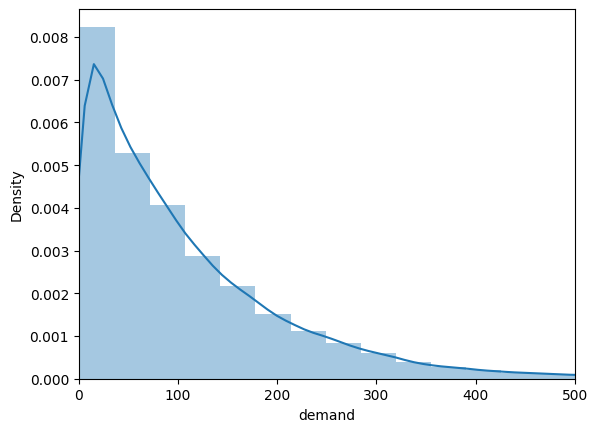

In [72]:
import seaborn as sns
plt.xlim(0,500)
sns.distplot(demand["demand"])

<Axes: ylabel='demand'>

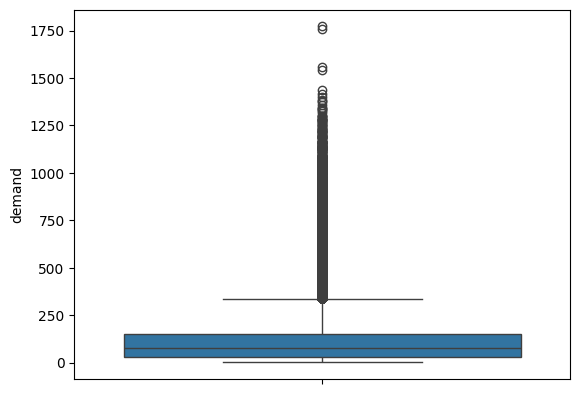

In [73]:
sns.boxplot(demand['demand'])

In [74]:
demand['demand'].skew()

np.float64(2.6674815831472998)

<Axes: xlabel='dow', ylabel='demand'>

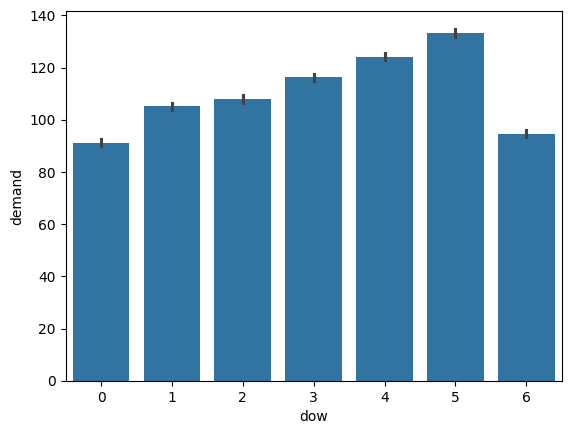

In [75]:
sns.barplot(x =demand['dow'] ,y = demand['demand'])

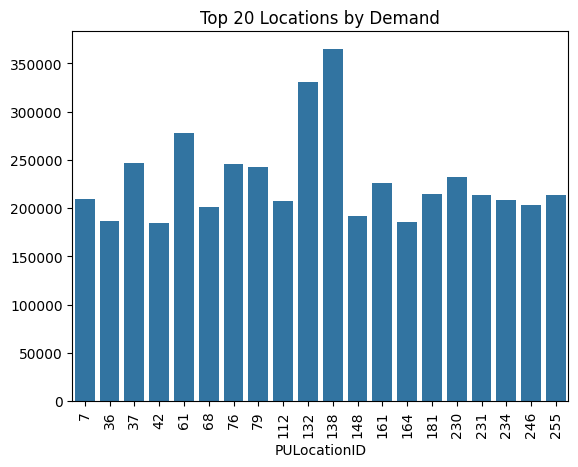

In [76]:
top_locations = demand.groupby('PULocationID')['demand'].sum().sort_values(ascending=False).head(20)

sns.barplot(x=top_locations.index, y=top_locations.values)

plt.xticks(rotation=90)
plt.title("Top 20 Locations by Demand")
plt.show()

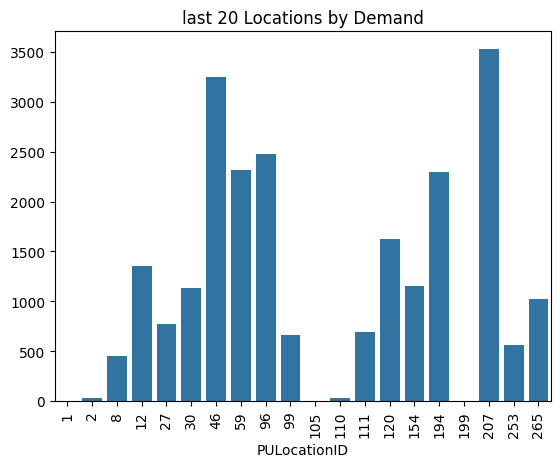

In [77]:
top_locations = demand.groupby('PULocationID')['demand'].sum().sort_values().head(20)

sns.barplot(x=top_locations.index, y=top_locations.values)

plt.xticks(rotation=90)
plt.title("last 20 Locations by Demand")
plt.show()

<Axes: xlabel='hour', ylabel='demand'>

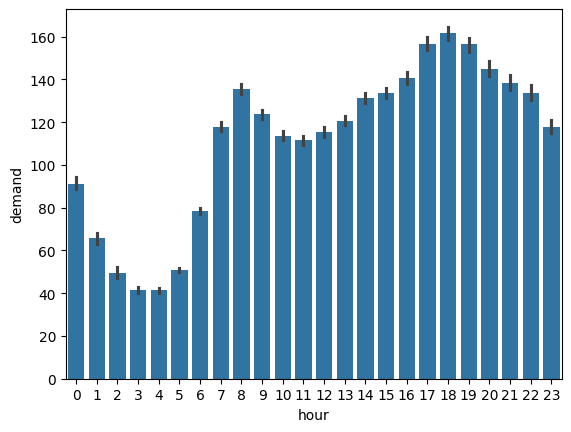

In [78]:
sns.barplot(x = demand['hour'] , y =demand['demand'])

In [79]:
import numpy as np
demand['new_demand'] = np.log1p(demand['demand'])

In [80]:
demand

,PULocationID,hour,dow,pre_demand,demand,new_demand
0,1,12,3,1.0,1,0.693147
1,2,12,3,1.0,1,0.693147
2,2,21,4,1.0,1,0.693147
3,2,10,0,1.0,1,0.693147
4,2,16,0,1.0,1,0.693147
...,...,...,...,...,...,...
187287,265,18,5,6.0,3,1.386294
187288,265,19,5,3.0,5,1.791759
187289,265,20,5,5.0,3,1.386294
187290,265,21,5,3.0,4,1.609438


C:\Users\koner\AppData\Local\Temp\ipykernel_4784\1955954414.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(demand["new_demand"])


<Axes: xlabel='new_demand', ylabel='Density'>

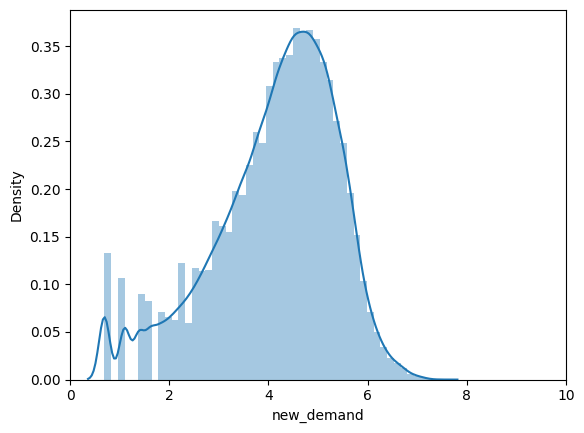

In [81]:
plt.xlim(0,10)
sns.distplot(demand["new_demand"])

In [82]:
demand.describe()

,PULocationID,hour,dow,pre_demand,demand,new_demand
count,187292.000000,187292.000000,187292.000000,187292.000000,187292.000000,187292.000000
mean,134.157503,11.558929,3.099444,111.600560,111.787284,4.136197
std,75.824673,6.901223,1.939167,120.440672,120.563332,1.246867
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.693147
25%,68.000000,6.000000,1.000000,30.000000,30.000000,3.433987
50%,136.000000,12.000000,3.000000,76.000000,76.000000,4.343805
75%,200.000000,18.000000,5.000000,153.000000,153.000000,5.036953
max,265.000000,23.000000,6.000000,1772.000000,1772.000000,7.480428


In [83]:
demand['demand'].var()

14535.51699438704

In [84]:
demand['new_demand'].var()

1.5546780979287236

In [85]:
demand[['demand','pre_demand']].corr()

,demand,pre_demand
demand,1.000000,0.944312
pre_demand,0.944312,1.000000


In [86]:
demand[['hour','dow','demand','pre_demand']].corr()

,hour,dow,demand,pre_demand
hour,1.000000,-0.002447,0.242184,0.237794
dow,-0.002447,1.000000,0.053413,0.058864
demand,0.242184,0.053413,1.000000,0.944312
pre_demand,0.237794,0.058864,0.944312,1.000000


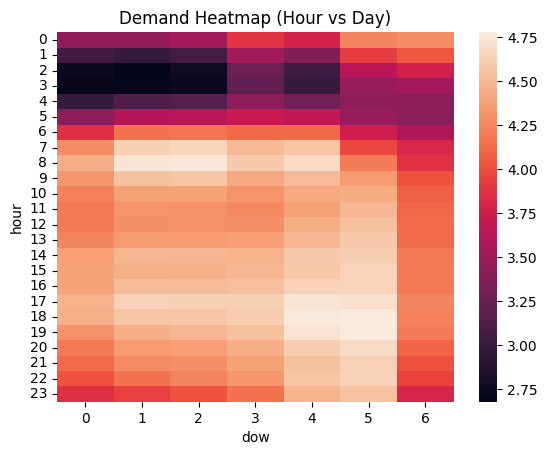

In [87]:
pivot = demand.pivot_table(
    index="hour",
    columns="dow",
    values="new_demand",
    aggfunc="mean"
)

sns.heatmap(pivot)
plt.title("Demand Heatmap (Hour vs Day)")
plt.show()

In [88]:
demand

,PULocationID,hour,dow,pre_demand,demand,new_demand
0,1,12,3,1.0,1,0.693147
1,2,12,3,1.0,1,0.693147
2,2,21,4,1.0,1,0.693147
3,2,10,0,1.0,1,0.693147
4,2,16,0,1.0,1,0.693147
...,...,...,...,...,...,...
187287,265,18,5,6.0,3,1.386294
187288,265,19,5,3.0,5,1.791759
187289,265,20,5,5.0,3,1.386294
187290,265,21,5,3.0,4,1.609438


In [91]:
demand

,PULocationID,hour,dow,pre_demand,demand,new_demand
0,1,12,3,1.0,1,0.693147
1,2,12,3,1.0,1,0.693147
2,2,21,4,1.0,1,0.693147
3,2,10,0,1.0,1,0.693147
4,2,16,0,1.0,1,0.693147
...,...,...,...,...,...,...
187287,265,18,5,6.0,3,1.386294
187288,265,19,5,3.0,5,1.791759
187289,265,20,5,5.0,3,1.386294
187290,265,21,5,3.0,4,1.609438


In [94]:
x = demand.iloc[:,0:4]

In [95]:
x.shape

(187292, 4)

In [96]:
y = demand.iloc[:,-1]

In [97]:
y

0         0.693147
1         0.693147
2         0.693147
3         0.693147
4         0.693147
            ...   
187287    1.386294
187288    1.791759
187289    1.386294
187290    1.609438
187291    1.098612
Name: new_demand, Length: 187292, dtype: float64

In [98]:
from sklearn.model_selection  import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [99]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [101]:
models = {
    "Linear": LinearRegression(),
    "RF": RandomForestRegressor(),
    "XGB": XGBRegressor()
}

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    from sklearn.metrics import mean_absolute_error
    print(name, mean_absolute_error(y_test, pred))

Linear 0.5892646125374416
RF 0.20098280412396546
XGB 0.19043023052154873


In [102]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

model = XGBRegressor()

param_grid = {
    "n_estimators": [100, 200,300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1
)

grid.fit(x_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [103]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}


In [104]:
from xgboost import XGBRegressor

xgb= XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1
)

In [105]:
xgb.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [106]:
y_pred = xgb.predict(x_test)

In [107]:
import numpy as np

pred_actual = np.expm1(y_pred)
y_actual = np.expm1(y_test)

In [108]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_actual, pred_actual)
print("Final MAE:", mae)

Final MAE: 14.525663578411073


In [109]:
xgb.predict([[220 , 20 , 5 , 60]])

array([4.08801], dtype=float32)

In [110]:
np.expm1(demand['new_demand'].mean())

np.float64(61.56445989996597)

In [111]:
import pickle

In [112]:
import joblib

joblib.dump(xgb, "demand_model.pkl")

['demand_model.pkl']

In [113]:
import numpy as np

pred_log = xgb.predict([[261, 9, 1, 120]])
pred_actual = np.expm1(pred_log)

print(pred_actual)

[97.93979]


In [114]:
x.shape

(187292, 4)